# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 3: Generative Adversarial Networks
## Question 2: Vanilla GAN on Swiss Roll

In this assignment, we train a vanilla GAN on the 2D Swiss-roll dataset. The goal is to make the alternating min-max loop concrete and to visualize how training behaves before moving to a more realistic dataset.


### Loading Modules
Let's load some required modules.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Device:', device)


Device: mps


### Swiss Roll Dataset

We use a 2D projection of the Swiss-roll manifold. We chose this data, as it is cheap to generate. To synthesize the dataset, we could use `make_swiss_roll` in the `sklearn.datasets` module.


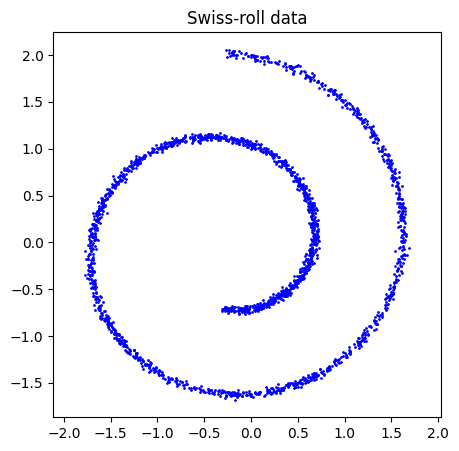

In [2]:
from sklearn.datasets import make_swiss_roll

# Complete the function that synthesize a dataset with `n_samples` samples
def make_swiss_roll_2d(n_samples=2048, noise=0.15, standardize=True):
    X, _ = make_swiss_roll(n_samples=n_samples, noise=noise)
    X = X[:, [0, 2]]  # keep the 2D unrolled plane, drop the height axis
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X

# Generate a dataset
x_data = make_swiss_roll_2d(n_samples=2048, noise=0.15, standardize=True)


# Plot the scattering diagram of the dataset
plt.figure(figsize=(5, 5))
plt.scatter(x_data[:, 0], x_data[:, 1], c='blue', s=1)
plt.title('Swiss-roll data')
plt.axis('equal')
plt.show()

#### Data Loader

Now, let's put the dataset in batches and build the loaders.


In [3]:
batch_size = 256

tensor_data = torch.tensor(x_data, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(tensor_data)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



### Models
We now implement simple generator and discriminator to train via min-max game on this dataset. 

#### Discriminator
The discriminator is to get a 2D input $x$ and classify it as `real` or `fake`. We consider the following MLP:
$$
\mathrm{Linear} (2 \rightarrow 64) + \mathrm{LeakyReLU}\\
\downarrow\\
\mathrm{Linear} (64 \rightarrow 64) + \mathrm{LeakyReLU}\\
\downarrow\\
\mathrm{Linear} (64 \rightarrow 64) + \mathrm{LeakyReLU}\\
\downarrow\\
\mathrm{Linear} (64 \rightarrow 1)
$$
For all $\mathrm{LeakyReLU}$ activations set $\texttt{negative\_slope}=0.2$. Note that the last layer should be properly activated for classification.

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        ## COMPLETE ##
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

#### Generator

For generator, we need a network which converts a 8D noise sample $z$ to a 2D data sample $x$. For this, we implement the following MLP:
$$
\mathrm{Linear} (8 \rightarrow 64) + \mathrm{ReLU}\\
\downarrow\\
\mathrm{Linear} (64 \rightarrow 64) + \mathrm{ReLU}\\
\downarrow\\
\mathrm{Linear} (64 \rightarrow 64) + \mathrm{ReLU}\\
\downarrow\\
\mathrm{Linear} (64 \rightarrow 2) 
$$


In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim = 8):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)



#### Sampling Loop

We finally write a function to sample the generator.


In [6]:
# Sample a noise sample z from N(0,1)
def sample_noise(n, z_dim=8):
    return torch.randn(n, z_dim, device=device)

# Pass it through the generator and plot the output
def plot_samples(generator, z_dim=8, title='Generated samples'):
    generator.eval()
    with torch.no_grad():
        z = sample_noise(2048, z_dim)
        samples = generator(z).cpu().numpy()
    plt.figure(figsize=(5, 5))
    plt.scatter(samples[:, 0], samples[:, 1], c='red', s=1)
    plt.title(title)
    plt.axis('equal')

### Training via Min-Max Game

We now implement the training loop. Recall that this is a nested two-tier loop. We consider a general nested loop with `n_inner` inner loop iterations for each outer iteration. 

In [7]:
def train_GAN(n_inner = 2, z_dim = 8, epochs = 400):

    # Define the loss needed for computing the objective of vanilla GAN
    criterion = nn.BCELoss()

    # instantiate the discriminator
    D = Discriminator().to(device)
    
    # instantiate the generator
    G = Generator(z_dim = z_dim).to(device)

    # Set learning rates
    lr_D = 2e-4
    lr_G = 2e-4

    # Set the optimizers
    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))


    history = {
        'd_loss': [],
        'g_loss': [],
        'd_real': [],
        'd_fake': [],
    }

    # start the loop
    for epoch in range(1, epochs + 1):
        d_loss_epoch = 0
        g_loss_epoch = 0
        d_real_epoch = 0
        d_fake_epoch = 0
        num_batches = 0

        for (x_real,) in loader:
            x_real = x_real.to(device)
            batch_size = x_real.size(0)
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Discriminator inner loop
            for _ in range (n_inner):
                opt_D.zero_grad()
                d_out_real = D(x_real)
                loss_d_real = criterion(d_out_real, real_labels)

                z = sample_noise(batch_size, z_dim)
                x_fake = G(z).detach()
                d_out_fake = D(x_fake)
                loss_d_fake = criterion(d_out_fake, fake_labels)

                loss_d = loss_d_real + loss_d_fake
                loss_d.backward()
                opt_D.step()

            # Generator Update
            opt_G.zero_grad()
            z = sample_noise(batch_size, z_dim)
            x_fake = G(z)
            d_out_fake = D(x_fake)
            loss_g = criterion(d_out_fake, real_labels)
            loss_g.backward()
            opt_G.step()

            with torch.no_grad():
                d_real_prob = D(x_real).mean().item()
                d_fake_prob = D(x_fake).mean().item()

            d_loss_epoch += loss_d.item()
            g_loss_epoch += loss_g.item()
            d_real_epoch += d_real_prob
            d_fake_epoch += d_fake_prob
            num_batches += 1

        # Update history
        history['d_loss'].append(d_loss_epoch / num_batches)
        history['g_loss'].append(g_loss_epoch / num_batches)
        history['d_real'].append(d_real_epoch / num_batches)
        history['d_fake'].append(d_fake_epoch / num_batches)

        if epoch % 100 == 0 or epoch == 1:
            print(f'Epoch {epoch:4d}/{epochs} | D loss: {history["d_loss"][-1]:.4f} | G loss: {history["g_loss"][-1]:.4f} | D(real): {history["d_real"][-1]:.3f} | D(fake): {history["d_fake"][-1]:.3f}')
    return G, history

### Numerical Experiments and Findings

We now train GAN on our dataset and check out the impact of various parameters.


#### Visualizing Generator
Let's first train the model for `n_inner = 2` and sample it to see the learned distribution.

Epoch    1/400 | D loss: 1.3719 | G loss: 0.6456 | D(real): 0.535 | D(fake): 0.524
Epoch  100/400 | D loss: 1.2917 | G loss: 0.7878 | D(real): 0.532 | D(fake): 0.467
Epoch  200/400 | D loss: 1.1746 | G loss: 0.8888 | D(real): 0.566 | D(fake): 0.433
Epoch  300/400 | D loss: 1.0985 | G loss: 1.0379 | D(real): 0.603 | D(fake): 0.399
Epoch  400/400 | D loss: 1.1316 | G loss: 1.0436 | D(real): 0.597 | D(fake): 0.398


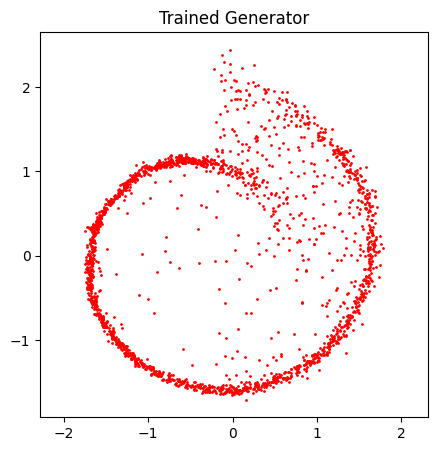

In [8]:
# train the model
G, history = train_GAN(n_inner = 2)

# use `plot_samples` to sample the trained model and plot it along with the true dataset
plot_samples(G, title='Trained Generator')


#### Loss Dynamics
We next plot the loss of the loss used by discriminator and generator. Note that when we train the generator, we could ignore the term corresponding to real samples. Also, we should take care of the inner loop's gradient by using the right sign. 

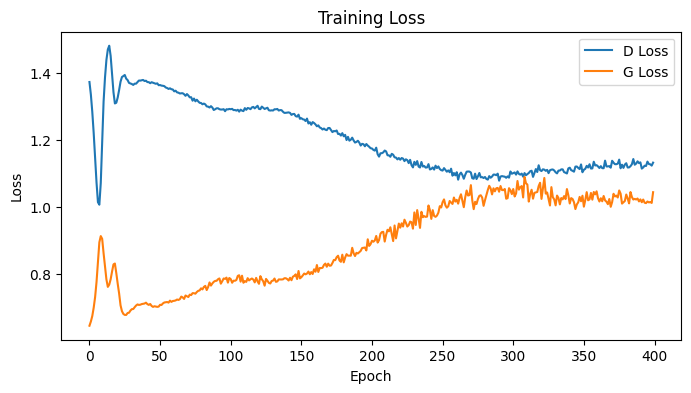

In [9]:
# Plot loss of G and D against epochs
plt.figure(figsize=(8, 4))
plt.plot(history['d_loss'], label='D Loss')
plt.plot(history['g_loss'], label='G Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

## Question: _Explain your observation._
Over the 400 epochs, discriminator loss decreases while generator loss increases. Both fluctuate heavily during the first ~30 epochs before settling into smoother trends. The two curves start far apart, with discriminator loss around 1.37 and generator loss around 0.65, and cross each other at around epoch 180. After that, generator loss remains consistently higher than discriminator loss for the rest of training, though the gap stays small (roughly 0.15) rather than continuing to widen. This pattern indicates the discriminator is gradually gaining an advantage over the generator as training progresses, rather than the two networks remaining in balance.

#### Confidence
We can now look at the discriminator's output to understand the confidence of the discriminator after training. 

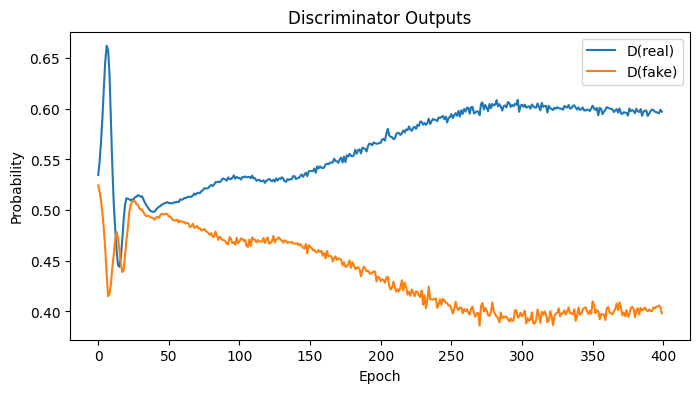

In [10]:
# Plot D(real) and D(fake) against epochs
plt.figure(figsize=(8, 4))
plt.plot(history['d_real'], label='D(real)')
plt.plot(history['d_fake'], label='D(fake)')
plt.xlabel('Epoch')
plt.ylabel('Probability')
plt.title('Discriminator Outputs')
plt.legend()
plt.show()

## Question: _Explain your observation. Does it make sense?_
D(real) is almost always higher than D(fake) over the 400 epochs. During the first ~25 epochs, both fluctuate heavily, briefly diverging then converging again to stay close to each other around epochs 25-50. After that, they part ways permanently, with D(real) steadily increasing while D(fake) steadily decreases, before both plateau around epoch 200. It makes sense because this mirrors the loss plot exactly: D(real) rising and D(fake) falling is the same underlying trend as discriminator loss decreasing and generator loss increasing, just expressed in probability space rather than loss space. As the discriminator becomes more confident and correct at separating real from fake samples, it assigns higher probability to real data and lower probability to fake data, which is exactly what falling D loss and rising G loss represent numerically. 

#### Impact of Inner Loop Convergence

Now we train the model with different `n_inner` and look at the visualization of each trained model.



Training GAN with n_inner=1
Epoch    1/400 | D loss: 1.3943 | G loss: 0.5938 | D(real): 0.555 | D(fake): 0.552
Epoch  100/400 | D loss: 1.4140 | G loss: 0.6954 | D(real): 0.507 | D(fake): 0.505
Epoch  200/400 | D loss: 1.3755 | G loss: 0.7094 | D(real): 0.499 | D(fake): 0.492
Epoch  300/400 | D loss: 1.3375 | G loss: 0.7319 | D(real): 0.512 | D(fake): 0.483
Epoch  400/400 | D loss: 1.3129 | G loss: 0.7481 | D(real): 0.521 | D(fake): 0.477
Training GAN with n_inner=2
Epoch    1/400 | D loss: 1.3768 | G loss: 0.7303 | D(real): 0.488 | D(fake): 0.482
Epoch  100/400 | D loss: 1.1870 | G loss: 0.9036 | D(real): 0.571 | D(fake): 0.431
Epoch  200/400 | D loss: 1.0210 | G loss: 1.1011 | D(real): 0.634 | D(fake): 0.373
Epoch  300/400 | D loss: 1.0422 | G loss: 1.1169 | D(real): 0.633 | D(fake): 0.358
Epoch  400/400 | D loss: 1.0440 | G loss: 1.0325 | D(real): 0.633 | D(fake): 0.366
Training GAN with n_inner=5
Epoch    1/400 | D loss: 1.3230 | G loss: 0.6835 | D(real): 0.540 | D(fake): 0.505
Epo

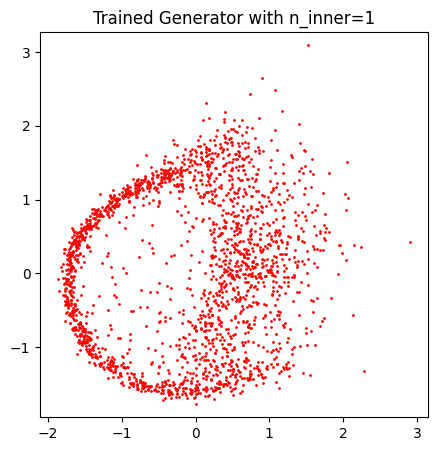

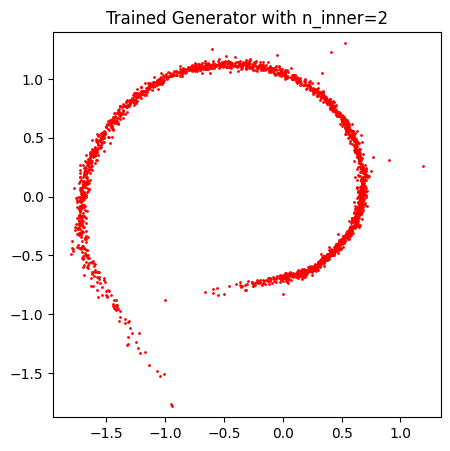

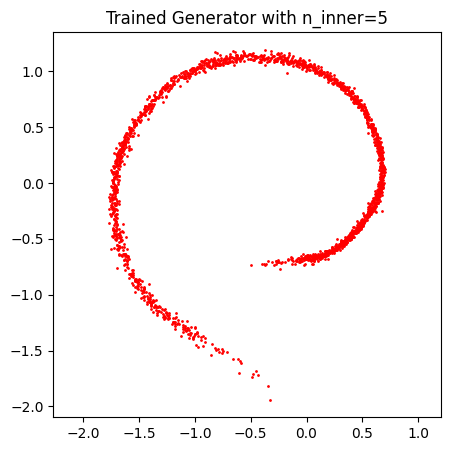

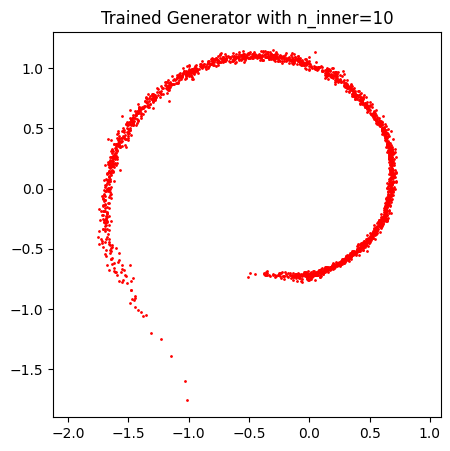

In [11]:
# Put it in a loop and look at the visualizations
for n_inner  in [1,2,5,10]:
    print(f'Training GAN with n_inner={n_inner}')
    G, history = train_GAN(n_inner = n_inner)
    plot_samples(G, title=f'Trained Generator with n_inner={n_inner}')


## Question: _Report your observation and explain it._
Lower n_inner (1, 2) reproduce the entire spiral without leaving large gaps, but with more per-point noise scattered around the arc. Higher n_inner (5, 10) produce a tighter, more precise fit along most of the arc, but leave an empty segment between the main arc and the tail end of the spiral. The tail end itself presents very few scattered points, but not as many as what appears throughout the n_inner (1, 2) outputs.


This suggests the discriminator has gained enough of an advantage that the generator stops trying to trace the full spiral precisely. Instead, it concentrates its output on the region that consistently fools the discriminator, at the cost of the small segment connecting to the tail that it fails to cover well.

#### Impact of Latent Space Dimension
We now play with the latent space dimension to see how it impacts the learning.

Training GAN with z_dim=1
Epoch    1/400 | D loss: 1.3746 | G loss: 0.6796 | D(real): 0.514 | D(fake): 0.507
Epoch  100/400 | D loss: 1.3688 | G loss: 0.7153 | D(real): 0.525 | D(fake): 0.497
Epoch  200/400 | D loss: 1.2336 | G loss: 0.8876 | D(real): 0.556 | D(fake): 0.432
Epoch  300/400 | D loss: 1.2908 | G loss: 0.7810 | D(real): 0.531 | D(fake): 0.466
Epoch  400/400 | D loss: 1.2453 | G loss: 0.8242 | D(real): 0.546 | D(fake): 0.450
Training GAN with z_dim=2
Epoch    1/400 | D loss: 1.3756 | G loss: 0.6975 | D(real): 0.504 | D(fake): 0.498
Epoch  100/400 | D loss: 1.3201 | G loss: 0.7472 | D(real): 0.521 | D(fake): 0.480
Epoch  200/400 | D loss: 1.2102 | G loss: 0.8737 | D(real): 0.562 | D(fake): 0.438
Epoch  300/400 | D loss: 1.2002 | G loss: 0.9050 | D(real): 0.568 | D(fake): 0.432
Epoch  400/400 | D loss: 1.2204 | G loss: 0.9356 | D(real): 0.566 | D(fake): 0.433
Training GAN with z_dim=4
Epoch    1/400 | D loss: 1.3815 | G loss: 0.6462 | D(real): 0.529 | D(fake): 0.524
Epoch  10

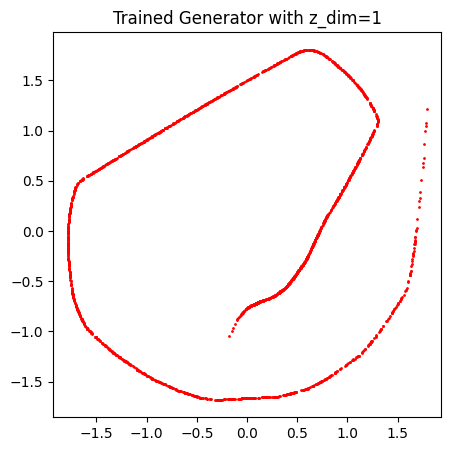

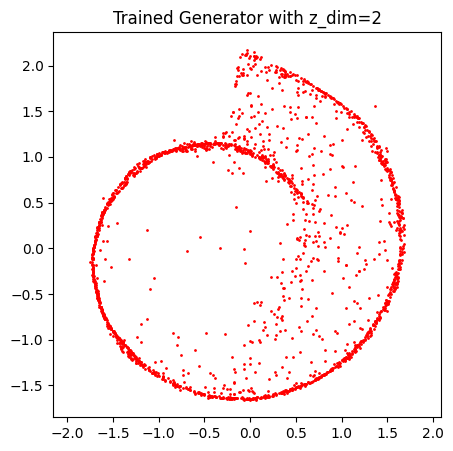

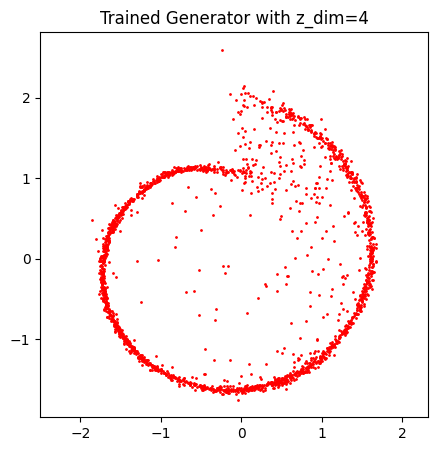

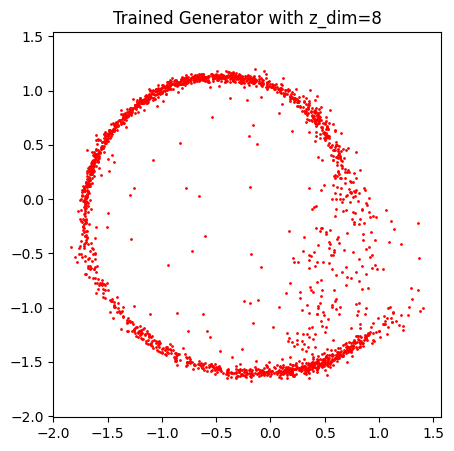

In [12]:
# Put it in a loop and look at the visualizations
for z_dim in [1,2,4,8]:
    print(f'Training GAN with z_dim={z_dim}')
    G, history = train_GAN(z_dim = z_dim)
    plot_samples(G, z_dim=z_dim, title=f'Trained Generator with z_dim={z_dim}')

## Question: _Report your observation and explain it._
At z_dim=1, the generator produces a smooth, single, non-self-intersecting curve. This is the theoretically expected result: a 1-dimensional latent space can only parameterize a 1-dimensional curve without folding, so no self-intersection is possible.

At z_dim=2 and z_dim=4, the generator's output consists of a tight, well-defined outer loop, closely matching the outer winding of the true data, along with a scattered, unstructured cluster of points filling part of the interior. Rather than a tight second loop, the interior region shows noise without a clear ring shape. This suggests the generator learned to fit the outer winding well but did not learn a comparably structured inner winding.

At z_dim=8, rather than a tight outer loop plus a separate interior noise cluster, the points form a single loop with a gap, and scatter is distributed around the entire loop rather than concentrated in the interior. This is a different failure pattern from z_dim=2 and 4, suggesting the larger latent space changes how the generator fails rather than resolving the issue.